files needed:
 - .csv from coronapp zip file (unarchived and located in the same directory as the code)
 - immun_epit_all3_HLA_Wuhan.csv (located in the same directory as the code)

# Datasets I and II

## Obtaining mutated epitopes

### Adding mutations to epitopes

The dictionary of this kind is being created:

protein name : 

      { [i] : 
      
            {start:, end:, 
            
            epitope before:[], current epitope:[] (after every patient is being returned to pre-mutated epitope), epitopes after: set(),

            number of mutations in one day:[], number of mutations for all days:[], hlas:[]}, ...}
            

Such a dictionary is being created for each patient

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [73]:
# dict to convert protein names from table with epitones to names from coronapp
# you need to have file 'immun_epit_all3_HLA_Wuhan.csv' downloaded and stored in the same dirrectory

prot_translation = {'leader':'NSP1', 'nsp2':'NSP2', 'nsp3':'NSP3', 'nsp4':'NSP4', '3C':'NSP5',
                    'nsp6':'NSP6', 'nsp7':'NSP7', 'nsp8':'NSP8', 'nsp9':'NSP9', 'nsp10':'NSP10',
                    'RdRp':'NSP12', 'helicase':'NSP13', 'exonuclease':'NSP14', 'endornase':'NSP15',
                    'methyltransferase':'NSP16', 'Spike':'S', 'ORF3a':'ORF3a', 'E':'E', 'M':'M',
                    'ORF6':'ORF6', 'ORF7a':'ORF7a', 'ORF7b':'ORF7b', 'ORF8':'ORF8', 'N':'N', 'ORF10':'ORF10'}

# creation of a dict, described upper
def create_fresh_epitops_dict():
    epits = pd.read_csv('immun_epit_all3_HLA_Wuhan.csv')
    epitops = {}
    for i, row in epits.iterrows():
        pept_name = prot_translation[row[0]]
        if pept_name not in epitops:
            epitops[pept_name] = {}
        start, end = row[3], row[4]
        epitop, hla = row[1], row[5]
        epitops[pept_name][i] = {}
        epitops[pept_name][i]['start'] = start
        epitops[pept_name][i]['end'] = end
        epitops[pept_name][i]['epi_before'] = epitop
        epitops[pept_name][i]['epi_curr'] = epitop
        epitops[pept_name][i]['epi_after'] = set()
        epitops[pept_name][i]['muts_per_patient'] = 0
        epitops[pept_name][i]['muts_all_time'] = 0
        epitops[pept_name][i]['hla'] = hla
        
    return epitops

Function below adds mutations to epitopes in different time points. 

Dict "epitopes" is being transmitted from one time point to another, and is being renewed for each patient.  

If there is a mutation in day 0 (in the earliest available sequence), and the mutation is absen in day n, we suppouse that it is present in every time point.  

In [74]:
# How to use this class:
# creation of an object : obj = Mutations_to_epitops(file, epitops, status) status = [ancestal, in patient
# to "mutate" ancestal obj: obj.epitops_mutations_ancestral()
# to "mutate" in_patient obj: obj.epitops_mutations_in_patient
# to get dataframe with mutated epitopes: obj.return_result_dataframe()
# to get a dictionary with mutated epitopes: obj.return_epitops_dict()
# to get number of mutations (any kind of mutations): obj.return_number_of_mutations()
# to get number if mutations in immunogenic epitopes: obj.return_number_of_immunogenic_mutations()


class Mutations_to_epitops:
    
    def __init__(self, filename, epitops, status):
        self.filename = filename
        self.epitops = epitops
        self.status = status
        self.cnt_mutations = 0
        self.cnt_immunogenic_mutations = 0
        self.result_df = None 
        
    # getter for a dataframe with mutated epitopes
    def return_result_dataframe(self):
        return self.result_df
    
    # getter for a dictionary with mutated epitopes
    def return_epitops_dict(self):
        return self.epitops
    
    # getter for a number of mutations
    def return_number_of_mutations(self):
        return self.cnt_mutations
    
    # getter for a number if mutations in immunogenic epitopes
    def return_number_of_immunogenic_mutations(self):
        return self.cnt_immunogenic_mutations
    
    # setter for adding mutations in epitopes on day 0 (ancestral)
    def epitops_mutations_ancestral(self):
        data = self.filename
        epitops = self.epitops
        df = pd.DataFrame({'sample':[], 'status':[],
                             'protein':[], 'mutations':[], 'ref_peptide':[], 'mut_peptide':[], 'Allele Name':[]})

        cnt_mutations = 0
        cnt_immunogenic_mutations = 0

        for i, row in data.iterrows():
            if row['refAA'] != row['qAA'] and row['qAA'] != '.':
                cnt_mutations += 1
                refpos = int(''.join(filter(str.isdigit, row['variant'])))
                #refpos = int(row['variant'][1:-1])
                pept_name = row['protein']
                if pept_name == 'NSP12a' or pept_name == 'NSP12b':
                    pept_name = 'NSP12'

                for epi in epitops[pept_name]:
                    if epitops[pept_name][epi]['start'] <= refpos <= epitops[pept_name][epi]['end']:
                        cnt_immunogenic_mutations += 1
                        change = refpos - epitops[pept_name][epi]['start']
                        mutated_epi = epitops[pept_name][epi]['epi_curr'][:change]+row['qAA']+epitops[pept_name][epi]['epi_curr'][change+1:]
                        epitops[pept_name][epi]['epi_curr'] = mutated_epi
    #                     if epitops[pept_name][i]['muts_per_patient'] == []:
    #                         epitops[pept_name][i]['muts_per_patient'].append(1)
                        epitops[pept_name][epi]['muts_per_patient'] = epitops[pept_name][epi]['muts_per_patient']+1

        for pept_name in epitops:
            for i in epitops[pept_name]:
                if epitops[pept_name][i]['epi_curr'] != epitops[pept_name][i]['epi_before']:

                    # epitops[pept_name][i]['epi_after'].add(epitops[pept_name][i]['epi_curr'])
                    # epitops[pept_name][i]['muts_all_time'] += 1

                    new_line = {'sample':row['sample'], 'status':row['status'], 'protein':pept_name,
                            'mutations':[],
                            'ref_peptide':epitops[pept_name][i]['epi_before'],
                            'mut_peptide':epitops[pept_name][i]['epi_curr'], 
                            'Allele Name':epitops[pept_name][i]['hla']}

                    epitops[pept_name][i]['epi_before'] = epitops[pept_name][i]['epi_curr']
                    epitops[pept_name][i]['muts_per_patient'] = 0

                    df = pd.concat([df, pd.DataFrame.from_records([new_line])], ignore_index=True)
        
        self.result_df = df
        self.epitops = epitops
        self.cnt_mutations = cnt_mutations
        self.cnt_immunogenic_mutations = cnt_immunogenic_mutations

        
    # setter for adding mutations in epitopes on day 1 and later (in_patient)
    def epitops_mutations_in_patient(self):
        data = self.filename
        epitops = self.epitops
        df = pd.DataFrame({'sample':[], 'status':[],
                             'protein':[], 'mutations':[], 'ref_peptide':[], 'mut_peptide':[], 'Allele Name':[]})

        cnt_mutations = 0
        cnt_immunogenic_mutations = 0

        for i, row in data.iterrows():
            if row['refAA'] != row['qAA'] and row['qAA'] != '.':
                cnt_mutations += 1
                refpos = int(''.join(filter(str.isdigit, row['variant'])))
                pept_name = row['protein']
                if pept_name == 'NSP12a' or pept_name == 'NSP12b':
                    pept_name = 'NSP12'

                for epi in epitops[pept_name]:
                    if epitops[pept_name][epi]['start'] <= refpos <= epitops[pept_name][epi]['end']:
                        cnt_immunogenic_mutations += 1
                        change = refpos - epitops[pept_name][epi]['start']
                        mutated_epi = epitops[pept_name][epi]['epi_curr'][:change]+row['qAA']+epitops[pept_name][epi]['epi_curr'][change+1:]
                        epitops[pept_name][epi]['epi_curr'] = mutated_epi
    #                     if epitops[pept_name][i]['muts_per_patient'] == []:
    #                         epitops[pept_name][i]['muts_per_patient'].append(1)
                        epitops[pept_name][epi]['muts_per_patient'] += 1

        for pept_name in epitops:
            for i in epitops[pept_name]:
                if epitops[pept_name][i]['epi_curr'] != epitops[pept_name][i]['epi_before']:


                    epitops[pept_name][i]['epi_after'].add(epitops[pept_name][i]['epi_curr'])
                    epitops[pept_name][i]['muts_all_time'] += 1

                    new_line = {'sample':row['sample'], 'status':row['status'], 'protein':pept_name,
                            'mutations':[],
                            'ref_peptide':epitops[pept_name][i]['epi_before'],
                            'mut_peptide':epitops[pept_name][i]['epi_curr'], 
                            'Allele Name':epitops[pept_name][i]['hla']}

                    epitops[pept_name][i]['epi_curr'] = epitops[pept_name][i]['epi_before']
                    epitops[pept_name][i]['muts_per_patient'] = 0

                    df = pd.concat([df, pd.DataFrame.from_records([new_line])], ignore_index=True)
                
        self.result_df = df
        self.epitops = epitops
        self.cnt_mutations = cnt_mutations
        self.cnt_immunogenic_mutations = cnt_immunogenic_mutations           


In [75]:
# The code below changes tables we got from coronapp, 
# so they became more convininet to use for further anaysis and delete deletions. 

def make_classic(filename, status):
    folder_name = "coronapp"
    data = pd.read_csv(f"{folder_name}/{filename}.csv")
    data.insert(5, 'refAA', '.', allow_duplicates = False)
    data.insert(6, 'qAA', '.', allow_duplicates = False)
    data.insert(7, 'status', '.', allow_duplicates = False)
    data = data.loc[data['varclass'] != 'extragenic']
    
    for i, row in data.iterrows():
        data.loc[i, 'status'] = status
        varname = str(row['varname']).split(':')
        data.loc[i, 'refAA'] = varname[1][0]
        if row['varclass'] != 'deletion':
            data.loc[i, 'qAA'] = varname[1][-1]
    return data

In [76]:
# the names of authors, files are named after them
names = ['Avanzato', 'Borges', 'Cele', 'Choi', 'Coguk1', 'Coguk2', 'Coguk3', 'Coguk4', 'Coguk5', 'Coguk6',
         'Kemp', 'Khatamzas', 'Quaranta', 'Reuken', 'Tarhini2',
         'Vellas1', 'Vellas2', 'Vellas3', 'Weigang']

# the names of files for each author and number of timepoints
info = [['Avanzato', 6], ['Borges', 2], ['Cele', 8], ['Choi', 9], 
        ['coguk1_', 2], ['coguk2_', 3], ['coguk3_', 3], ['coguk4_', 2], ['coguk5_', 5], ['coguk6_', 2],
        ['Kemp', 22], ['Khatamzas', 10], ['Quaranta', 3], ['Reuken', 2], 
        ['Vellas1_', 5], ['Vellas2_', 7], ['Vellas3_', 12], ['Vellas4_', 2], ['Weigang', 9], ['Stanevich', 6], 
       ['Cele', 7], ['Tarhini1_', 4], ['Tarhini2_', 3], ['Tarhini3_', 3]]

In [77]:
# this code uses files, listed in a cell upper and stored at the same dirrectory, 
# and extracts info about mutations in epitopes, using class Mutations_to_epitops for this. 
# As a single patient is prosessed, "Name processed" is printed

dict_total_inf = {}
for patient in info:
    surname = patient[0]
    n_of_samples = patient[1]
    dict_total_inf[surname] = {}
    filename_wt = surname + '_wt.csv'
    filenames_mut = [surname + str(i) for i in range(1, n_of_samples + 1)]
    for filename in filenames_mut:
        dict_total_inf[surname][filename] = {}
        dict_total_inf[surname][filename]['with_epitops'] = '-'
        dict_total_inf[surname][filename]['after_dict'] = '-'
        dict_total_inf[surname][filename]['number_of_mutations'] = '-'
        dict_total_inf[surname][filename]['number_of_immunogenic_mutations'] = '-'

    # here we get muttated epitopes and other information for day 0
    wt = make_classic(surname + '1', 'ancestral')
    filename_wt = Mutations_to_epitops(wt, create_fresh_epitops_dict(), 'ancestral')
    filename_wt.epitops_mutations_ancestral()
    wt_with_epitops = filename_wt.return_result_dataframe()
    dict_for_the_next_one = filename_wt.return_epitops_dict()
    wt_after_dict = filename_wt.return_epitops_dict()
    wt_number_of_mutations = filename_wt.return_number_of_mutations()
    wt_number_of_immunogenic_mutations = filename_wt.return_number_of_immunogenic_mutations()
    dict_total_inf[surname][filenames_mut[0]] = {}
    dict_total_inf[surname][filenames_mut[0]]['with_epitops'] = wt_with_epitops
    dict_total_inf[surname][filenames_mut[0]]['after_dict'] = dict_for_the_next_one
    dict_total_inf[surname][filenames_mut[0]]['number_of_mutations'] = wt_number_of_mutations
    dict_total_inf[surname][filenames_mut[0]]['number_of_immunogenic_mutations'] = wt_number_of_immunogenic_mutations
 


    # here we get muttated epitopes and other information for day 1 and later
    for filename in filenames_mut[1:]:
        dataframe = make_classic(filename, 'in_patient')
        filename_mut = Mutations_to_epitops(dataframe, dict_for_the_next_one, 'in_patient')
        filename_mut.epitops_mutations_in_patient()
        dict_total_inf[surname][filename]['with_epitops'] = filename_mut.return_result_dataframe()
        dict_total_inf[surname][filename]['after_dict'] = filename_mut.return_epitops_dict()
        dict_for_the_next_one = filename_mut.return_epitops_dict()
        dict_total_inf[surname][filename]['number_of_mutations'] = filename_mut.return_number_of_mutations()
        dict_total_inf[surname][filename]['number_of_immunogenic_mutations'] = filename_mut.return_number_of_immunogenic_mutations()

    mutated_epi_total = pd.DataFrame({'sample':[], 'status':[],
                                 'protein':[], 'mutations':[], 'ref_peptide':[], 'mut_peptide':[], 'Allele Name':[]})

    for filename in filenames_mut:
        mutated_epi_total = pd.concat([mutated_epi_total, 
                                       dict_total_inf[surname][filename]['with_epitops']], 
                                       ignore_index=True)
    print(mutated_epi_total.shape)
    print(f'{surname} processed')
    mutated_epi_total = mutated_epi_total.drop_duplicates(subset=['protein', 'mut_peptide', 'Allele Name'], keep='last', ignore_index=True)
    mutated_epi_total.to_csv(surname + '.csv', encoding='utf8')

(19, 7)
Avanzato processed
(45, 7)
Borges processed
(70, 7)
Cele processed
(93, 7)
Choi processed
(40, 7)
coguk1_ processed
(48, 7)
coguk2_ processed
(76, 7)
coguk3_ processed
(57, 7)
coguk4_ processed
(72, 7)
coguk5_ processed
(49, 7)
coguk6_ processed
(137, 7)
Kemp processed
(109, 7)
Khatamzas processed
(91, 7)
Quaranta processed
(31, 7)
Reuken processed
(127, 7)
Vellas1_ processed
(112, 7)
Vellas2_ processed
(731, 7)
Vellas3_ processed
(108, 7)
Vellas4_ processed
(42, 7)
Weigang processed
(97, 7)
Stanevich processed
(54, 7)
Cele processed
(26, 7)
Tarhini1_ processed
(10, 7)
Tarhini2_ processed
(24, 7)
Tarhini3_ processed


All info about a patient is saved in a dict dict_filenames_mut

- dict_filenames_mut[filename]['with_epitops'] - dataframe with mutated epitopes (for current timepoint)
- dict_filenames_mut[filename]['after_dict'] - dict with mutated epitopes (for current timepoint)
- dict_filenames_mut[filename]['number_of_mutations'] - number of mutations (for current timepoint)
- dict_filenames_mut[filename]['number_of_immunogenic_mutations'] - number of mutations, located in immunogenic epitopes (for current timepoint)

In [16]:
# code below turns files into info, suitable for netMHCpan run

# def netMHCpan_prep(filename):
#     data = pd.read_csv(filename)
#     txt_pept_name_wt = filename + '_qpeptids_wt' + '.txt'
#     txt_pept_name_mut = filename + '_qpeptids_mut' + '.txt'
#     txt_hla_name = filename + '_hla' + '.txt'
    
#     peptids_wt = open(txt_pept_name_wt, "w+")
#     peptids_mut = open(txt_pept_name_mut, "w+")
#     mass_peptids_wt = []
#     mass_peptids_mut = []
#     hla = open(txt_hla_name, "w+")
#     mass_hla = []
#     for i, row in data.iterrows():
#         if row['ref_peptide'] not in mass_peptids_wt:
#             peptids_wt.write(row['ref_peptide'] + '\n')
#             mass_peptids_wt.append(row['ref_peptide'])
#         if row['mut_peptide'] not in mass_peptids_mut:
#             peptids_mut.write(row['mut_peptide'] + '\n')
#             mass_peptids_mut.append(row['mut_peptide'])
#         if row['Allele Name'] not in mass_hla:
#             hla.write(row['Allele Name'] + ',')
#             mass_hla.append(row['Allele Name'])
    
    
#     peptids_wt.close()
#     peptids_mut.close()
#     hla.close()
            
    
# print(netMHCpan_prep(surname))

Running netMHCpan is not really convinient, so code below unites dataframes for different parients for one netMHCpan run. As the output we get list of epitopes, hlas and scripts. 

It will automatically ran files, listed in groups

In [23]:
info = [['Avanzato', 6], ['Borges', 2], ['Cele', 8], ['Choi', 9], 
        ['coguk1_', 2], ['coguk2_', 3], ['coguk3_', 3], ['coguk4_', 2], ['coguk5_', 5], ['coguk6_', 2],
        ['Kemp', 22], ['Khatamzas', 10], ['Quaranta', 3], ['Reuken', 2], ['Tarhini2_', 2], 
        ['Vellas1_', 5], ['Vellas2_', 7], ['Vellas3_', 12], ['Vellas4_', 2], ['Weigang', 9]]

groups = [[['Avanzato', 6], ['Borges', 2], ['Choi', 9]],
          [['coguk1_', 2], ['coguk2_', 3], ['coguk3_', 3], ['coguk4_', 2], ['coguk5_', 5], ['coguk6_', 2]],
         [['Kemp', 22]],
         [['Khatamzas', 10], ['Quaranta', 3], ['Reuken', 2], ['Vellas1_', 5], ['Vellas2_', 7]], 
         [['Vellas3_', 12], ['Vellas4_', 2], ['Weigang', 9]],
         [['Stanevich', 6], ['Cele', 7], ['Tarhini1_', 4], ['Tarhini2_', 3], ['Tarhini3_', 3]]]

In [35]:
cnt_scripts = 0


for group in groups:
    hlas = set()
    total_wt = open('n'+str(cnt_scripts)+'_qpeptids_wt.txt', "w+")
    total_mut = open('n'+str(cnt_scripts)+'_qpeptids_mut.txt', "w+")
    
    for patient in group:
        name = patient[0]
        df = pd.read_csv(name + '.csv')
        for i, row in df.iterrows():
            hlas.add(row['Allele Name'])
            total_wt.write(row['ref_peptide'] + '\n')
            total_mut.write(row['mut_peptide'] + '\n')
            
    total_wt.close()
    total_mut.close()
    hlas = list(hlas)
    hlas = ','.join(hlas)
    write_script_please_Arcuda(hlas, cnt_scripts)
    cnt_scripts += 1

print(cnt_scripts)

6


In [34]:
# This cell created script for one of used clasters

def write_script_please_Arcuda(hlas, n):
    n = str(n)
    output_wt = ''.join(['#!/bin/bash', '\n', 
        '#PBS -d .', '\n', 
        '#PBS -l walltime=10:00:00', '\n', 
        '/gss/home/e.riumina/netMHCpan-4.1/netMHCpan -p /gss/home/e.riumina/Yasya_Guest/n', n, 
        '_qpeptids_wt.txt -BA -xls -a ', hlas, ' -xlsfile /gss/home/e.riumina/Yasya_Guest/n', n, '_wt.xls'])
    output_mut = ''.join(['#!/bin/bash', '\n', 
        '#PBS -d .', '\n', 
        '#PBS -l walltime=10:00:00', '\n', 
        '/gss/home/e.riumina/netMHCpan-4.1/netMHCpan -p /gss/home/e.riumina/Yasya_Guest/n', n, 
        '_qpeptids_mut.txt -BA -xls -a ', hlas, ' -xlsfile /gss/home/e.riumina/Yasya_Guest/n', n, '_mut.xls'])
    script_wt = open('n'+n+'_wt_net_MHCpan_script.sh', "w+")
    script_wt.write(output_wt)
    script_wt.close()
    script_mut = open('n'+n+'_mut_net_MHCpan_script.sh', "w+")
    script_mut.write(output_mut)
    script_mut.close()

In [1]:
# This cell created script for another used clasters

def write_script_please_Babilon(hlas, n):
    n = str(n)
    output_wt = ''.join(['#!/bin/bash', '\n', 
        '#PBS -l walltime=600:00:00', '\n', 
        '/home/ryumina_ed/gpfs/netMHCpan-4.1/netMHCpan -p /home/ryumina_ed/gpfs/folder/n', n, 
        '_qpeptids_wt.txt -BA -xls -a ', hlas, ' -xlsfile /home/ryumina_ed/gpfs/folder/n', n, '_wt.xls'])
    output_mut = ''.join(['#!/bin/bash', '\n', 
        '#PBS -l walltime=600:00:00', '\n', 
        '/home/ryumina_ed/gpfs/netMHCpan-4.1/netMHCpan -p /home/ryumina_ed/gpfs/folder/n', n, 
        '_qpeptids_mut.txt -BA -xls -a ', hlas, ' -xlsfile /home/ryumina_ed/gpfs/folder/n', n, '_mut.xls'])
    script_wt = open('n'+n+'_wt_net_MHCpan_script.sh', "w+")
    script_wt.write(output_wt)
    script_wt.close()
    script_mut = open('n'+n+'_mut_net_MHCpan_script.sh', "w+")
    script_mut.write(output_mut)
    script_mut.close()

In [352]:
import matplotlib.pyplot as plt
from matplotlib import cm
import cmasher as cmr
from colorspacious import cspace_converter

import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

## Processing netMHCpan output

In [38]:
import re

In [39]:
groups = [[['Avanzato', 6], ['Borges', 2], ['Choi', 9]],
          [['coguk1', 2], ['coguk2', 3], ['coguk3', 3], ['coguk4', 2], ['coguk5', 5], ['coguk6', 2]],
         [['Kemp', 22]],
         [['Khatamzas', 10], ['Quaranta', 3], ['Reuken', 2], ['Vellas1_', 5], ['Vellas2_', 7]], 
         [['Vellas3_', 12], ['Vellas4_', 2], ['Weigang', 9]],
         [['Stanevich', 6], ['Cele', 7], ['Tarhini1_', 4], ['Tarhini2_', 3], ['Tarhini3_', 3]]]

In [40]:
def fix_header_MHCpan(file_name):
    snp_MHC_names =pd.read_csv(file_name, sep='\t', header = [1], nrows=3)
    snp_MHC_hlas =pd.read_csv(file_name, sep='\t', header = 0, nrows=2).columns
    hlas = ['']
    hlas+=[i for i in snp_MHC_hlas if i.startswith('HLA') for j in range(2)]
    to_del = [i for i in snp_MHC_names.columns if ('Pos'in i) | ('ID' in i) | ('NB' in i)| ('core' in i)| ('icore' in i)|('Ave' in i)]
    names_col = [i for i in snp_MHC_names.columns if i not in to_del]
    my_list = []
    for chunk in pd.read_csv(file_name, sep='\t', header = 1, usecols = names_col, chunksize=50000):
        chunk[chunk.select_dtypes(np.float64).columns] = chunk.select_dtypes(np.float64).astype(np.float32)
        my_list.append(chunk)
    snp_MHC = pd.concat(my_list, axis= 0)
    del my_list
    new = [m+' ' + str(n) for m,n in zip(hlas,snp_MHC.columns)]
    new_2 = [re.sub('\.\d*', '', i) for i in new]
    snp_MHC.columns = new_2
    del snp_MHC_names, snp_MHC_hlas, new 
    return snp_MHC


# the following function merges the wt_netMHC file (with ranks for ancestral epitopes),
# mut_netMHC (with ranks for mutated epitopes) and your original table,
# in which the epitopes are in the "peptide" column


def fromNetMHCpan(table):
    table = pd.read_csv(table)
    tables = []
    for hla in set(table['Allele Name'].values):
        table_before_hla = table[table['Allele Name'] == hla]
        columns_netMHC = [' Peptide']
        # filters the column names of the wt_netMHC DataFrame, leaving only those column names
        # that start with the hla substring, and converts them to a list
        columns_netMHC += wt_netMHC.columns[wt_netMHC.columns.str.startswith(hla)].to_list()

        table_wt = wt_netMHC[columns_netMHC].drop_duplicates()
        table_mut = mut_netMHC[columns_netMHC].drop_duplicates()
        
        table_before_hla_wt = table_before_hla.merge(table_wt, left_on = 'ref_peptide', right_on = ' Peptide', how = 'left')
        table_before_hla_wt.rename(columns={hla + ' EL_Rank':'wt_EL_Rank', hla + ' BA_Rank':'wt_BA_Rank'}, inplace=True)
        table_before_hla_wt_mut = table_before_hla_wt.merge(table_mut, left_on = 'mut_peptide', right_on = ' Peptide', how = 'left')
        table_before_hla_wt_mut.rename(columns={hla + ' EL_Rank':'mut_EL_Rank', hla + ' BA_Rank':'mut_BA_Rank'}, inplace=True)
        tables.append(table_before_hla_wt_mut)
    all_country_after = pd.concat(tables)
    all_country_after = all_country_after.drop([' Peptide_x', ' Peptide_y'], axis=1)
    return all_country_after  


def make_mark_EL(row):
    if (row['mut_EL_Rank'] <=2) & (row['wt_EL_Rank'] <=2) & (row['mut_EL_Rank'] >= 1.5*row['wt_EL_Rank']):
        return 'Decreased binding'
    elif (row['wt_EL_Rank'] <=2) & (row['mut_EL_Rank'] < row['wt_EL_Rank']) & (1.5*row['mut_EL_Rank'] <= row['wt_EL_Rank']):
        return 'Increased binding'
    elif (row['mut_EL_Rank'] > 2) & (row['wt_EL_Rank'] <=2):
        return 'Lost binding'
    elif row['wt_EL_Rank'] > 2:
        return 'No binding'
    else:
        return 'Same binding'


# to run code below you need output from netMHCpan, named like m_wt.xls and m_mut.xls stored in the same dirrectory
# and original table (surname + '.csv')

for n in range(len(groups)):
    MHCpan_fixed_headings_wt = fix_header_MHCpan('m' + str(n) + '_wt.xls')
    MHCpan_fixed_headings_mut = fix_header_MHCpan('m' + str(n) + '_mut.xls')

    print(n, 'fix_header_MHCpan was successful, output parameters:', MHCpan_fixed_headings_wt.shape)
    
    wt_netMHC = MHCpan_fixed_headings_wt
    mut_netMHC = MHCpan_fixed_headings_mut
    
    for el in groups[n]:
        surname = el[0]
        changed_binding = fromNetMHCpan(surname + '.csv')
        print(surname, 'fromNetMHCpan was successful, output parameters:', changed_binding.shape)

        changed_binding['EL_mark'] = changed_binding.apply(lambda row: make_mark_EL(row), axis=1).astype("str")
        print(surname, 'make_mark_EL was successful, output parameters:', changed_binding.shape)
        changed_binding.to_csv(surname + '_changed_binding.csv', encoding='utf8')

0 fix_header_MHCpan was successful, output parameters: (127, 51)
Avanzato fromNetMHCpan was successful, output parameters: (19, 12)
Avanzato make_mark_EL was successful, output parameters: (19, 13)
Borges fromNetMHCpan was successful, output parameters: (45, 12)
Borges make_mark_EL was successful, output parameters: (45, 13)
Choi fromNetMHCpan was successful, output parameters: (63, 12)
Choi make_mark_EL was successful, output parameters: (63, 13)
1 fix_header_MHCpan was successful, output parameters: (322, 63)
coguk1 fromNetMHCpan was successful, output parameters: (40, 12)
coguk1 make_mark_EL was successful, output parameters: (40, 13)
coguk2 fromNetMHCpan was successful, output parameters: (48, 12)
coguk2 make_mark_EL was successful, output parameters: (48, 13)
coguk3 fromNetMHCpan was successful, output parameters: (65, 12)
coguk3 make_mark_EL was successful, output parameters: (65, 13)
coguk4 fromNetMHCpan was successful, output parameters: (57, 12)
coguk4 make_mark_EL was success

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import cmasher as cmr

In [25]:
info = [['Avanzato', 6], ['Borges', 2], ['Cele', 8], ['Choi', 9], 
        ['coguk1_', 2], ['coguk2_', 3], ['coguk3_', 3], ['coguk4_', 2], ['coguk5_', 5], ['coguk6_', 2],
        ['Kemp', 22], ['Khatamzas', 10], ['Quaranta', 3], ['Reuken', 2], ['Tarhini2_', 2], 
        ['Vellas1_', 5], ['Vellas2_', 7], ['Vellas3_', 12], ['Vellas4_', 2], ['Weigang', 9]]

groups = [[['Avanzato', 6], ['Borges', 2], ['Choi', 9]],
          [['Coguk1', 2], ['Coguk2', 3], ['Coguk3', 3], ['Coguk4', 2], ['Coguk5', 5], ['Coguk6', 2]],
         [['Kemp', 22]],
         [['Khatamzas', 10], ['Quaranta', 3], ['Reuken', 2], ['Vellas1_', 5], ['Vellas2_', 7]], 
         [['Vellas3_', 12], ['Vellas4_', 2], ['Weigang', 9]],
         [['Stanevich', 6], ['Cele', 7], ['Tarhini1_', 4], ['Tarhini2_', 3], ['Tarhini3_', 3]]]

In [6]:
import pandas as pd
import cmasher as cmr
import numpy as np

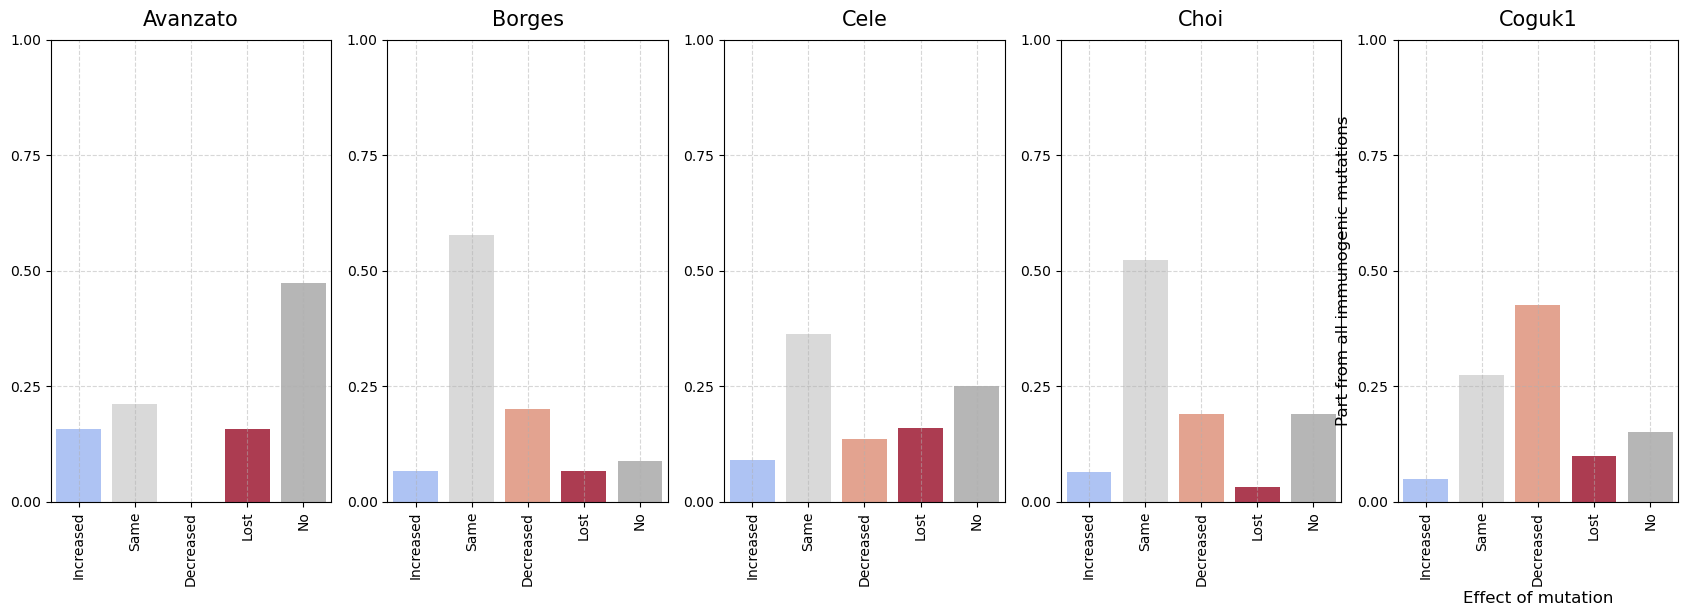

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 5, figsize=(21, 6))
names = ['Avanzato', 'Borges', 'Cele', 'Choi', 'Coguk1'] 
# names = ['Coguk2', 'Coguk3', 'Coguk4', 'Coguk5', 'Coguk6']
# names = ['Kemp', 'Khatamzas', 'Quaranta', 'Reuken', 'Tarhini2']
# names = ['Vellas1', 'Vellas2', 'Vellas3', 'Weigang', 'Stanevich']
# names = ['Tarhini1_', 'Tarhini3_', 'Vellas4_']
# Loop through the 6 different dataframes

for i in range(len(names)):
    df = pd.read_csv(names[i] + '_changed_binding.csv')
    df = pd.DataFrame(df.reset_index())
    
    ax = axs[i]
    colors_o = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
    colors_outer = [colors_o[5], 'lightgrey', colors_o[15], colors_o[19], 'darkgrey']
    
    category_counts = dict(df['EL_mark'].value_counts())
    labels = ['Increased binding', 'Same binding', 'Decreased binding', 'Lost binding', 'No binding']
    values = []
    for el in labels:
        if el in category_counts:
            values.append(category_counts[el])
        else:
            values.append(0)
    values = [el / sum(values) for el in values]
    
    sns.barplot(x=labels, y=values, color='grey', alpha=0.85, palette=colors_outer,
                order=['Increased binding', 'Same binding', 'Decreased binding', 'Lost binding', 'No binding'], ax=ax)
    
    ax.yaxis.set_ticks(np.linspace(0, 1, 5))
    ax.set_yticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'], rotation=0, fontsize=10)
    ax.set_xticklabels(['Increased', 'Same', 'Decreased', 'Lost', 'No'], fontsize=10, rotation=90)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.text(2, 1.03, names[i], fontsize=15, horizontalalignment='center')

#    ax.set_title('N = ' + str(int(df.shape[0])), fontsize=12)
#    plt.savefig(surname + '_barplot.png')

plt.xlabel('Effect of mutation', fontsize = 12)
plt.ylabel('Part from all immunogenic mutations', fontsize = 12)
plt.show()

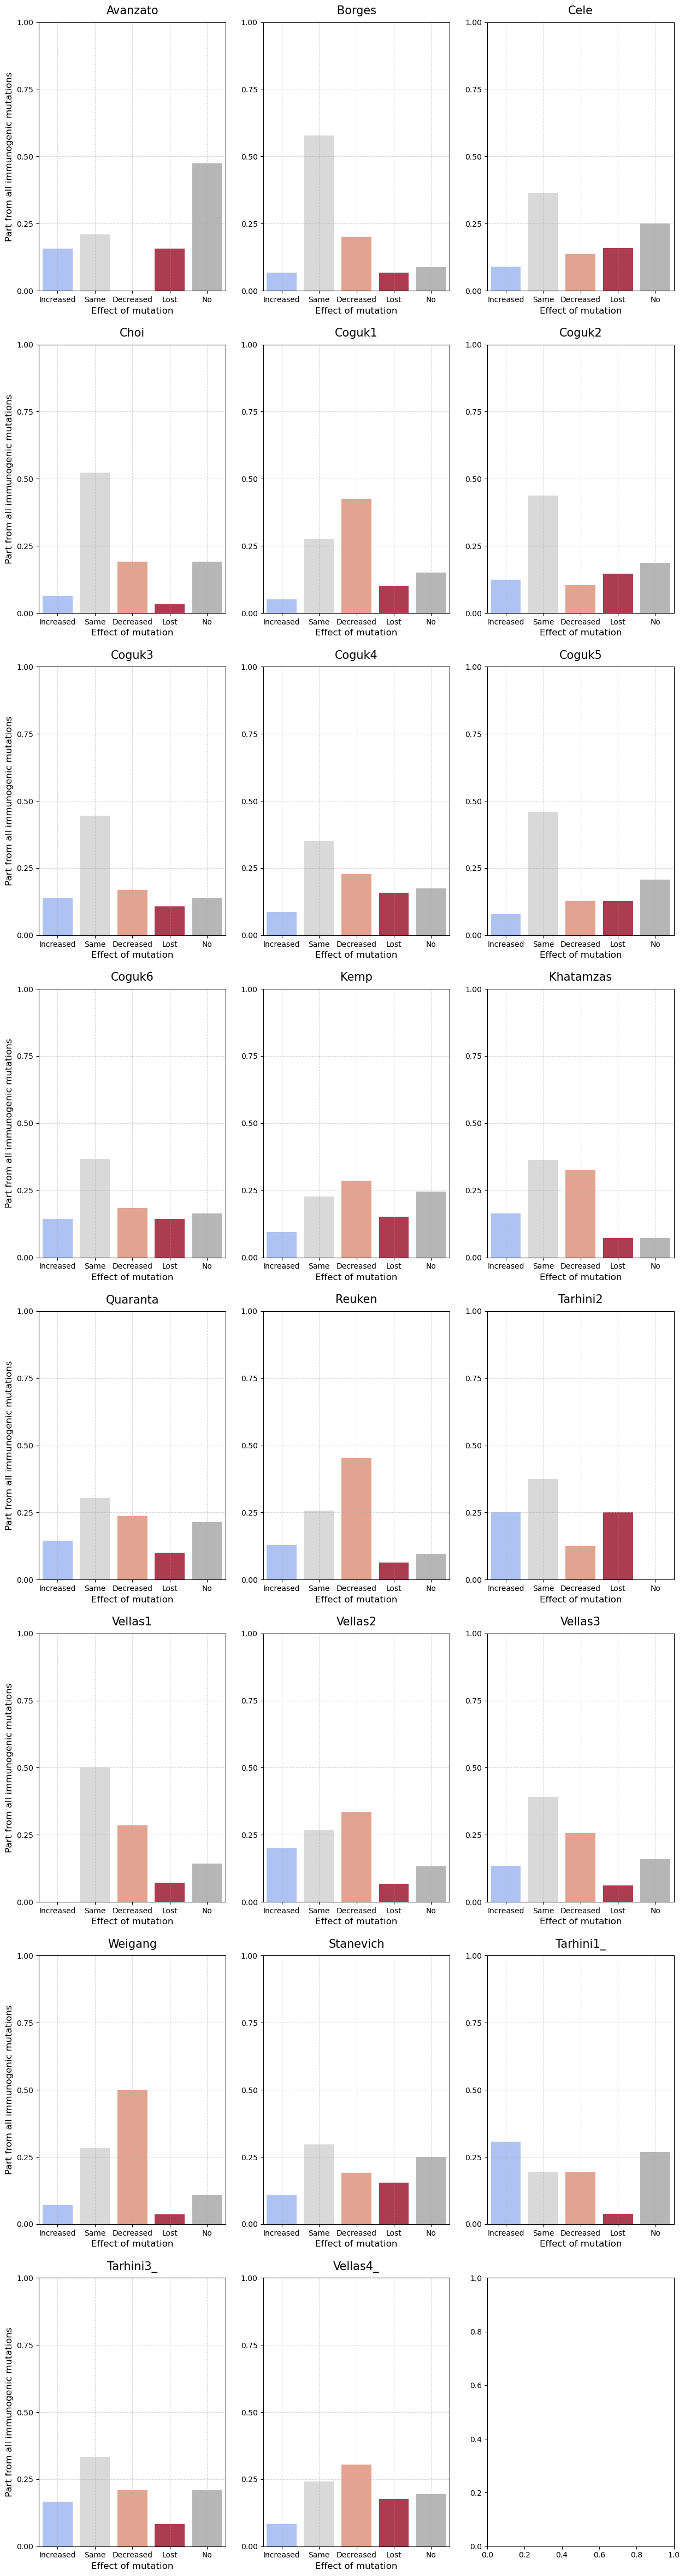

In [61]:
fig, axs = plt.subplots(8, 3, figsize=(15, 60))

everyone = [['Avanzato', 'Borges', 'Cele'],
           ['Choi', 'Coguk1', 'Coguk2'],
           ['Coguk3', 'Coguk4', 'Coguk5'], 
           ['Coguk6', 'Kemp', 'Khatamzas'],
           ['Quaranta', 'Reuken', 'Tarhini2'],
           ['Vellas1', 'Vellas2', 'Vellas3'],
           ['Weigang', 'Stanevich', 'Tarhini1_'],
           ['Tarhini3_', 'Vellas4_']]

for i in range(len(everyone)):
    axs[i, 0].set_ylabel('Part from all immunogenic mutations', fontsize = 12)
    for j in range(len(everyone[i])):
        df = pd.read_csv(everyone[i][j] + '_changed_binding.csv')
        df = pd.DataFrame(df.reset_index())

        ax = axs[i, j]
        colors_o = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
        colors_outer = [colors_o[5], 'lightgrey', colors_o[15], colors_o[19], 'darkgrey']

        category_counts = dict(df['EL_mark'].value_counts())
        labels = ['Increased binding', 'Same binding', 'Decreased binding', 'Lost binding', 'No binding']
        values = []
        for el in labels:
            if el in category_counts:
                values.append(category_counts[el])
            else:
                values.append(0)
        values = [el / sum(values) for el in values]

        sns.barplot(x=labels, y=values, color='grey', alpha=0.85, palette=colors_outer,
                    order=['Increased binding', 'Same binding', 'Decreased binding', 'Lost binding', 'No binding'], ax=ax)

        ax.yaxis.set_ticks(np.linspace(0, 1, 5))
        ax.set_yticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'], rotation=0, fontsize=10)
        ax.set_xticklabels(['Increased', 'Same', 'Decreased', 'Lost', 'No'], fontsize=10, rotation=0)

        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.text(2, 1.03, everyone[i][j], fontsize=15, horizontalalignment='center')
        ax.set_xlabel('Effect of mutation', fontsize = 12)


    #    ax.set_title('N = ' + str(int(df.shape[0])), fontsize=12)

plt.show()

Code below needs to be run for every single patient separately (with the correct country of origin, countries of origin could are taken from papers or from corresponding authors)

In [ ]:
cb = pd.read_csv('Stanevich_changed_binding.csv', index_col=0)
cb_unique = cb.drop_duplicates(subset=['peptide', 'Allele Name'])
cb_unique.to_csv('Stanevich_changed_binding.csv', encoding='utf8')
cb_unique.rename(columns={'refpeptide': 'ref_peptide', 'peptide': 'mut_peptide'}, inplace=True)
cb_format = cb_unique[['sample', 'status', 'protein', 'ref_peptide', 'mut_peptide', 'Allele Name', 'wt_EL_Rank', 'wt_BA_Rank', 'mut_EL_Rank', 'mut_BA_Rank', 'EL_mark']]
cb_format.loc[:, 'Origin'] = 'Russia Moscow' 
cb_format.loc[:, 'Оrigin_confidence'] = 1.0
cb_format.loc[:, 'Country'] = 'Russia'
cb_format.loc[:, 'Article'] = 'Stanevich'

cb_format.to_csv('Stanevich_for_katya.csv', encoding='utf8')

In [ ]:
files = ['Tarhini2_for_katya.csv', 'Kemp_for_katya.csv', 'Stanevich_for_katya.csv', 
        'Weigang_for_katya.csv', 'Coguk1_for_katya.csv', 'Coguk2_for_katya.csv', 'Coguk3_for_katya.csv',
        'Coguk4_for_katya.csv', 'Coguk5_for_katya.csv', 'Coguk6_for_katya.csv', 'Reuken_for_katya.csv',
        'Khatamzas_for_katya.csv', 'Quaranta_for_katya.csv', 'Vellas1_for_katya.csv', 'Vellas2_for_katya.csv',
        'Vellas3_for_katya.csv', 'Vellas4_for_katya.csv', 'Borges_for_katya.csv']

df = pd.concat( 
    map(pd.read_csv, files), ignore_index=True)
df = df.drop('Unnamed: 0.2', axis=1)
df = df.drop('Unnamed: 0.1', axis=1)
df = df.drop('Unnamed: 0', axis=1)

df.to_csv('everyone_17.csv', encoding='utf8')

# Datasets III and IV

## Up to netMHCpan

### Dataset III

In [ ]:
import pandas as pd
britmut = pd.read_csv("Fig6/british2.csv") #file containing coronapp output for the patients
brit_snp = britmut.query("varclass == 'SNP'")
brit_snp["key"] = brit_snp['sample'].str.split('|').str[1].str.split("_").str[1].astype(int)
kusti = []
ready = []

patients = [el.split("|")[1].split("_")[0] for el in brit_snp["sample"].unique()]
#this part of the code generates "kusti" variable containing groups of lists of mutations from related samples
for patient in patients:
    if patient not in ready and int(patient[1:]) > 11: #this filter is used to only keep delta and omicron samples
        pat_filt = brit_snp[brit_snp['sample'].str.split("|").str[1].str.split("_").str[0] == patient]
        
        pat_sorted = pat_filt.copy()
        pat_sorted['key'] = pat_sorted['sample'].str.split("|").str[1].str.split("_").str[1].astype(int)
        pat_sorted = pat_sorted.sort_values(by='key')
        
        samples = pat_sorted["sample"].unique()
        forkusti = []
        
        for smpl in samples:
            kust = list(brit_snp.query("sample == @smpl")["varname"].values)
            forkusti.append(kust)
        
        kusti.append(forkusti)
        ready.append(patient)


for el in kusti:
    for el1 in el:
        for mut in el1:
            if mut == "NSP12b:P314L":
                el1.remove(mut)
                el1.append("NSP12b:P323L")
            elif mut == "S:GE339DK":
                el1.remove(mut)
                el1.append("S:G339D")
                el1.append("S:E340K")

#this part creates two files: "epitopes_before.txt" and "epitopes_after.txt" containing epitope sequences present in the patients before and after the intrahost evolution
#both of them are subsequently fed to netMHCpan
#requires "immun_epit_all2_HLA_Wuhan.csv" file containing epitope coordinates and sequences from the reference viral variant
#it also creates a local variable lst_of_alleles containing HLA alleles corresponding to each epitope

epitopes = []
with open("immun_epit_all3_HLA_Wuhan.csv") as im:
    im.readline()
    for line in im.readlines():
        epitopes.append([line.split("\t")[0], int(line.split("\t")[3]), int(line.split("\t")[4]), line.split("\t")[1], line.split("\t")[5].strip()])
dct_of_prt = {"leader":"NSP1",
             "nsp2":"NSP2",
             "nsp3":"NSP3",
             "nsp4":"NSP4",
             "3C":"NSP5",
             "nsp6":"NSP6",
             "nsp7":"NSP7",
             "nsp8":"NSP8",
             "nsp9":"NSP9",
             "nsp10":"NSP10",
             "RdRp":"NSP12b",
             "helicase":"NSP13",
             "exonuclease":"NSP14",
             "endornase":"NSP15",
             "methyltransferase":"NSP16",
             "Spike":"S",
             "E":"E",
             "ORF3a":"ORF3a",
             "M":"M",
             "ORF6":"ORF6",
             "ORF7a":"ORF7a",
             "ORF7b":"ORF7b",
             "ORF8":"ORF8",
             "N":"N",
             "ORF10":"ORF10"
             }
lst_of_alleles = []
group_ids = []
def intr(epitop, mutlist):
    prot = epitop[0]
    seq = list(epitop[3])
    seq1 = epitop[3]
    start = epitop[1]
    end = epitop[2]
    relevent_mutations = []
    for mt in mutlist:
        if dct_of_prt[prot] == mt.split(":")[0] and "N:RG" not in mt:
            try:
                pos = int(mt.split(":")[1][1:-1])
            except:
                print(mt)
            if pos >= start and pos <= end:
                seq[pos - start] = mt.split(":")[1][-1]
                relevent_mutations.append(mt)
    return ("".join(seq), relevent_mutations)
lst_of_alleles = []
relevent_mutations=[]
for elem in range(len(kusti)):
    with open("epitopes_before.txt", mode = "a+") as epitb:
        with open("epitopes_after.txt", mode = "a+") as epita:
            for epitop in epitopes:
                do = intr(epitop, kusti[elem][0])
                posle = []
                for psl in kusti[elem][1:]:
                    if intr(epitop, psl) not in posle:
                        posle.append(intr(epitop, psl))
                for psl in posle:
                    if do[0] != psl[0]:
                        lst_of_alleles.append(epitop[-1])
                        group_ids.append(elem)
                        relevent_mutations.append([el for el in psl[1] if el not in do[1]])
                        epitb.write(do[0])
                        epitb.write("\n")
                        epita.write(psl[0])
                        epita.write("\n")

### Dataset IV

In [ ]:
import re
dict_per_sample_nucl_mut = {}
with open("Fig6/all_chronic-like_paths.txt") as onik:
    for line in onik.readlines():
        dict_per_sample_nucl_mut[line.split("|")[1]] = dict_per_sample_nucl_mut.get(line.split("|")[1], []) + re.findall("[ATGC]{1}[0-9]{1,}[ATGC]{1}", line)
with open("Fig6/reference.fasta") as rf:
    rf.readline()
    genome = rf.readline()
reference = list(genome)
with open("Fig6/270_for_coronapp.fasta", mode = "a+") as coron:
    for k, v in dict_per_sample_nucl_mut.items():
        coron.write(">")
        coron.write(k)
        coron.write("\n")
        new_gen = reference.copy()
        for mut in v:
            new_gen[int(mut[1:-1]) - 1] = mut[-1]
        coron.write("".join(new_gen))
        coron.write("\n")
#270_for_coronapp.fasta file is used for coronapp

In [ ]:
import pandas as pd

pat = pd.read_csv("Fig6/within_clade_mutations.csv") #"within_clade_mutations.csv" contains information about groups of related samples
pat = pat.query("clade in ['21I', '21J', '21L', '21K', '22B', '22C']") #keeping only delta and omicron samples
ids = list(pat["epi"].values)
patients = pd.read_csv("Fig6/270_all_coronout.csv").query("sample in @ids") #"270_all_coronout.csv" contains coronapp output for the set of sequences in 270_for_coronapp.fasta file

#this part of the code creates a list of lists, each corresponding to a group of related samples and containing sets of mutations fo each sample
countrydict = {}
with open("Fig6/all_chronic-like_paths.txt") as pth: #"all_chronic-like_path.txt" file contains paths from UsHER tree for all the samples
    for line in pth.readlines():
        countrydict[line.split("|")[1]] = line.split("/")[0]
kusti = []
countries = []
for node in pat["id"].unique():
    pat_filt = pat.query("id == @node")
    pat_filt['date'] = pd.to_datetime(pat_filt['date'])
    pat_sorted = pat_filt.sort_values(by='date')
    samples = pat_sorted["epi"].values
    countries.append(samples[0])
    forkusti = []
    for smpl in samples:
        kust = list(patients.query("sample == @smpl").query("varclass == 'SNP'")["varname"].values)
        forkusti.append(kust)
    kusti.append(forkusti)
    
#this part removes/converts some mutation names for further manipulations
for el in kusti:
    for el1 in el:
        for mut in el1:
            if mut == "NSP12b:P314L":
                el1.remove(mut)
                el1.append("NSP12b:P323L")
            elif mut == "S:GE339DK":
                el1.remove(mut)
                el1.append("S:G339D")
                el1.append("S:E340K")
#this part creates two files: "epitopes_before.txt" and "epitopes_after.txt" containing epitope sequences present in the patients before and after the intrahost evolution
#both of them are subsequently fed to netMHCpan
#requires "immun_epit_all2_HLA_Wuhan.csv" file containing epitope coordinates and sequences from the reference viral variant
#it also creates a local variable lst_of_alleles containing HLA alleles corresponding to each epitope, local variable group_ids containing identifiers for each group of related samples
epitopes = []
with open("immun_epit_all3_HLA_Wuhan.csv") as im:
    im.readline()
    for line in im.readlines():
        epitopes.append([line.split("\t")[0], int(line.split("\t")[3]), int(line.split("\t")[4]), line.split("\t")[1], line.split("\t")[5].strip()])
dct_of_prt = {"leader":"NSP1",
             "nsp2":"NSP2",
             "nsp3":"NSP3",
             "nsp4":"NSP4",
             "3C":"NSP5",
             "nsp6":"NSP6",
             "nsp7":"NSP7",
             "nsp8":"NSP8",
             "nsp9":"NSP9",
             "nsp10":"NSP10",
             "RdRp":"NSP12b",
             "helicase":"NSP13",
             "exonuclease":"NSP14",
             "endornase":"NSP15",
             "methyltransferase":"NSP16",
             "Spike":"S",
             "E":"E",
             "ORF3a":"ORF3a",
             "M":"M",
             "ORF6":"ORF6",
             "ORF7a":"ORF7a",
             "ORF7b":"ORF7b",
             "ORF8":"ORF8",
             "N":"N",
             "ORF10":"ORF10"
             }
lst_of_alleles = []
group_ids = []
def intr(epitop, mutlist):
    prot = epitop[0]
    seq = list(epitop[3])
    seq1 = epitop[3]
    start = epitop[1]
    end = epitop[2]
    relevent_mutations = []
    for mt in mutlist:
        if dct_of_prt[prot] == mt.split(":")[0] and "N:RG" not in mt:
            try:
                pos = int(mt.split(":")[1][1:-1])
            except:
                print(mt)
            if pos >= start and pos <= end:
                seq[pos - start] = mt.split(":")[1][-1]
                relevent_mutations.append(mt)
    return (("".join(seq), relevent_mutations))
lst_of_alleles = []
c = 0
relevent_mutations=[]
for elem in kusti:
    with open("epitopes_before.txt", mode = "a+") as epitb:
        with open("epitopes_after.txt", mode = "a+") as epita:
            for epitop in epitopes:
                do = intr(epitop, elem[0])
                posle = []
                for psl in elem[1:]:
                    if intr(epitop, psl) not in posle:
                        posle.append(intr(epitop, psl))
                for psl in posle:
                    if do[0] != psl[0]:
                        lst_of_alleles.append(epitop[-1])
                        group_ids.append(countries[c])
                        epitb.write(do[0])
                        epitb.write("\n")
                        epita.write(psl[0])
                        epita.write("\n")
    c+=1

## Processing netMHCpan output

In [ ]:
import pandas as pd
import numpy as np
import re
def fix_header_MHCpan(file_name): #this function modifies netMHCpan output tables to make them more legible
    snp_MHC_names =pd.read_csv(file_name, sep='\t', header = [1], nrows=3)
    snp_MHC_hlas =pd.read_csv(file_name, sep='\t', header = 0, nrows=2).columns
    hlas = ['']
    hlas+=[i for i in snp_MHC_hlas if i.startswith('HLA') for j in range(2)]
    to_del = [i for i in snp_MHC_names.columns if ('Pos'in i) | ('ID' in i) | ('NB' in i)| ('core' in i)| ('icore' in i)|('Ave' in i)]
    names_col = [i for i in snp_MHC_names.columns if i not in to_del]
    my_list = []
    for chunk in pd.read_csv(file_name, sep='\t', header = 1, usecols = names_col, chunksize=50000):
        chunk[chunk.select_dtypes(np.float64).columns] = chunk.select_dtypes(np.float64).astype(np.float32)
        my_list.append(chunk)
    snp_MHC = pd.concat(my_list, axis= 0)
    del my_list
    new = [m+' ' + str(n) for m,n in zip(hlas,snp_MHC.columns)]
    new_2 = [re.sub('\.\d*', '', i) for i in new]
    snp_MHC.columns = new_2
    del snp_MHC_names, snp_MHC_hlas, new 
    return snp_MHC

wt = fix_header_MHCpan("wt.xls") #"wt.xls" file contains xls output of netMHCpan for file "epitopes_before.txt"
mut = fix_header_MHCpan("mut.xls") #"mut.xls" file contains xls output of netMHCpan for file "epitopes_after.txt"

effects = []
for i in range(len(lst_of_alleles)):
    bef = wt[lst_of_alleles[i] + " EL_Rank"][i]
    epitop_bef = wt[" Peptide"][i]
    aft = mut[lst_of_alleles[i] + " EL_Rank"][i]
    epitop_aft = mut[" Peptide"][i]
    effects.append((bef, aft, epitop_bef, epitop_aft))

with open("immune_effects_for_Katya_with_epi_3.txt", "a+") as Katya:
    Katya.write("Allele" + "\t" + "Country" + "\t" + "epitope_before" + "\t" + "epitope_after" + "\t" + "score_before" + "\t" + "score_after" + "\t" + "mutations" + "\t" + "id")
    Katya.write("\n")
    for i in range(len(lst_of_alleles)):
        Katya.write(lst_of_alleles[i] + "\t" + countrydict[group_ids[i]] + "\t" + str(effects[i][2]) + "\t" + str(effects[i][3])+ "\t" + str(effects[i][0]) + "\t" + str(effects[i][1]) + "\t" + ",".join(relevent_mutations[i]) + "\t" + group_ids[i])
        Katya.write("\n")

In [ ]:
import pandas as pd
import numpy as np
import re
def fix_header_MHCpan(file_name): #this function modifies netMHCpan output tables to make them more legible
    snp_MHC_names =pd.read_csv(file_name, sep='\t', header = [1], nrows=3)
    snp_MHC_hlas =pd.read_csv(file_name, sep='\t', header = 0, nrows=2).columns
    hlas = ['']
    hlas+=[i for i in snp_MHC_hlas if i.startswith('HLA') for j in range(2)]
    to_del = [i for i in snp_MHC_names.columns if ('Pos'in i) | ('ID' in i) | ('NB' in i)| ('core' in i)| ('icore' in i)|('Ave' in i)]
    names_col = [i for i in snp_MHC_names.columns if i not in to_del]
    my_list = []
    for chunk in pd.read_csv(file_name, sep='\t', header = 1, usecols = names_col, chunksize=50000):
        chunk[chunk.select_dtypes(np.float64).columns] = chunk.select_dtypes(np.float64).astype(np.float32)
        my_list.append(chunk)
    snp_MHC = pd.concat(my_list, axis= 0)
    del my_list
    new = [m+' ' + str(n) for m,n in zip(hlas,snp_MHC.columns)]
    new_2 = [re.sub('\.\d*', '', i) for i in new]
    snp_MHC.columns = new_2
    del snp_MHC_names, snp_MHC_hlas, new 
    return snp_MHC

wt = fix_header_MHCpan("wt.xls") #"wt.xls" file contains xls output of netMHCpan for file "epitopes_before.txt"
mut = fix_header_MHCpan("mut.xls") #"mut.xls" file contains xls output of netMHCpan for file "epitopes_after.txt"

effects = []
for i in range(len(lst_of_alleles)):
    bef = wt[lst_of_alleles[i] + " EL_Rank"][i]
    epitop_bef = wt[" Peptide"][i]
    aft = mut[lst_of_alleles[i] + " EL_Rank"][i]
    epitop_aft = mut[" Peptide"][i]
    effects.append((bef, aft, epitop_bef, epitop_aft))
    
with open("immune_effects_for_Katya_with_epi_BRIT.txt", "a+") as Katya:
    Katya.write("Allele" + "\t" + "Country" + "\t" + "epitope_before" + "\t" + "epitope_after" + "\t" + "score_before" + "\t" + "score_after" + "\t" + "mutations" + "\t" + "id")
    Katya.write("\n")
    for i in range(len(lst_of_alleles)):
        Katya.write(lst_of_alleles[i] + "\t" + "Britain" + "\t" + str(effects[i][2]) + "\t" + str(effects[i][3])+ "\t" + str(effects[i][0]) + "\t" + str(effects[i][1]) + "\t" + ",".join(relevent_mutations[i]) + "\t" + str(group_ids[i]))
        Katya.write("\n")

# For Fig 6

In [5]:
#files needed: everyone_17.csv, immune_effects_for_Katya_with_epi_BRIT.txt, immune_effects_for_Katya_with_epi_3.txt

import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
from scipy import stats
import math
from scipy.stats import mannwhitneyu
import glob
from matplotlib.colors import LinearSegmentedColormap
from collections import Counter
import collections
import cmasher as cmr
import glob
from scipy.stats import ttest_ind
from scipy.stats import combine_pvalues
from matplotlib.patches import PathPatch
def stars(num):
    text = ''
    p = 0.051
    count = 0

    while num < p:
        count+=1
        text += '*'
        p /= 10.
        if count%3 == 0:
            text += '\n'
    return text

def barplot_annotate_brackets_ax(num1, num2, data, center, height, yerr=False, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        text = ''
        p = 0.05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    #if yerr:
    #    ly += yerr[num1]
    #    ry += yerr[num2]

    #ax_y0, ax_y1 = plt.gca().get_ylim()
    #dh *= (ax_y1 - ax_y0)
    #barh *= (ax_y1 - ax_y0)

    #y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)
    axs.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs
    
    axs.text(*mid, text, **kwargs)

def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.01, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = 0.05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    #if yerr:
    #    ly += yerr[num1]
    #    ry += yerr[num2]

    #ax_y0, ax_y1 = plt.gca().get_ylim()
    #dh *= (ax_y1 - ax_y0)
    #barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

import seaborn as sns
from matplotlib import pyplot as plt

def make_mark_EL(row):
    if (row['score_after'] <=2) & (row['score_before'] <=2) & (row['score_after'] >= 1.5*row['score_before']):
        return 'Decreased binding'
    elif (row['score_before'] <=2) & (row['score_after'] < row['score_before'])& (1.5*row['score_after'] <= row['score_before']):
        return 'Increased binding'
    elif (row['score_after'] >2) & (row['score_before'] <=2):
        return 'Lost binding'
    elif row['score_before'] >2:
        return 'No binding'
    else:
        return 'Same'


def picture(df, lost_mean, incr_mean, name, save):
    #print(df[(df['x'] == 'impaired_population')&(df['Allele frequency']>lost_mean)].shape[0]/1000, 
    #      df[(df['x'] == 'increased_population')&(df['Allele frequency']>incr_mean)].shape[0]/1000)
    #print(df[(df['x'] == 'increased_population')&(df['Allele frequency']>lost_mean)].shape[0]/1000)

    variable="Allele frequency"
    category="x"
    colors = ['red', 'white', 'blue', 'white']
    xticks = ['Impaired\nPopulation',#\nmed = %.2e' %np.median(datas[0]), 
                  'Impaired\nImmuno-',#\nmed = %.2e' %np.median(datas[1]),
                  'Increased\nPopulation',#\nmed = %.2e' %np.median(datas[2]),
                  'Increased\nImmuno-'#.\nmed = %.2e' %np.median(datas[3])
             ]
    category_order=['impaired_population','impaired_immunocompromised', 'increased_population', 'increased_immunocompromised']
    horizontal=False

    plt.figure()
    #table = d_tables_drivers[c].copy()
    #table['fraction_total'] = np.log10(table['fraction_total'])


    categories = ['impaired_population','impaired_immunocompromised', 'increased_population', 'increased_immunocompromised']
    figsize = (7, 1.25 * len(categories))

    fig, axes = plt.subplots(
            nrows=1,
            ncols=len(categories),
            figsize=figsize[::-1] if not horizontal else figsize,
            sharex=horizontal,
            sharey=not horizontal,
        )

    for i, (cat, c,xtick) in enumerate(zip(categories, colors, xticks)):
        ax = axes[i]
        keep_variable_axis = (i == len(fig.axes) - 1) if horizontal else (i == 0)
        if (i==0)|(i==2):
            sns.kdeplot(
                    data=df[df[category] == cat],
                    x=variable if horizontal else None,
                    y=None if horizontal else variable,
                    # kde kwargs
                    bw_adjust=0.5,
                    clip_on=False,
                    fill=True,
                    alpha=1,
                    linewidth=1.5,
                    ax=ax,
                    color=c,
                )
            sns.rugplot(
                        data=df[df[category] == cat],
                        x=variable if horizontal else None,
                        y=None if horizontal else variable,
                        ax=ax,
                        color="black",alpha = 0.1,
                        height=0.15,
                    )
        elif i == 1:
            tab = df[df['x'] == 'impaired_immunocompromised']
            sns.stripplot(x="x", y='Allele frequency', data=tab, ax=ax,linewidth = 0.1,
                          size=7,jitter =0.3, alpha=0.75,color = 'pink', edgecolor ='black')
            mn = np.mean(tab['Allele frequency'])
            mean = pd.DataFrame({'x':['impaired_immunocompromised'], 
                        'mean':[mn]})
            sns.stripplot(x="x", y='mean', data=mean, ax=ax,color = 'red',  alpha = 1, size = 9, jitter = 0)
            #ax.plot([-0.5,0],
            #            [mn,mn], linestyle='--', color = 'black',linewidth=2, alpha = 0.75)
            #lim = axes[0].get_xlim()
            #axes[0].plot(lim,
            #            [mn,mn], linestyle='--', color = 'black',linewidth=2, alpha = 0.75)
            #pv = df[(df['x'] == 'impaired_population')&(df['Allele frequency']>lost_mean)].shape[0]/1000
            lim = ax.get_xlim()
            ax.text((lim[0] + lim[1]) / 2, mn+0.005, '%.03f' %mn, fontsize=14, va="bottom", ha="center")
        elif i == 3:
            tab = df[df['x'] == 'increased_immunocompromised']
            sns.stripplot(x="x", y='Allele frequency', data=tab, ax=ax,linewidth = 0.1,
                          size=7,jitter =0.3, alpha=0.75,color = '#A1CAF1', edgecolor ='black')
            mn = np.mean(tab['Allele frequency'])
            mean = pd.DataFrame({'x':['increased_immunocompromised'], 
                        'mean':[mn]})
            sns.stripplot(x="x", y='mean', data=mean, ax=ax,color = 'blue',  alpha = 1, size = 9, jitter = 0)
            lim = ax.get_xlim()
            ax.text((lim[0] + lim[1]) / 2, mn+0.005, '%.03f' %mn, fontsize=14, va="bottom", ha="center")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_ylabel(' ', fontsize=18)
        if i >0:
            ax.spines["left"].set_visible(False)
        else:
            ax.set_ylabel('Allele frequency', fontsize=18)
        ax.set_xticklabels('', fontsize=14)   
        ax.set_xlabel(xtick, fontsize=14)
        ax.tick_params(axis = 'both', labelsize=14,color = 'white')
        ax.set_ylim(0,0.36)


    #axes[2].set_title(name, fontsize = 14, loc = 'right')
    #plt.tight_layout()
    axes[0].tick_params(axis = 'y', labelsize=14,color = 'black')
    plt.subplots_adjust(wspace = 0.06)
    if save:
        plt.savefig('Fig6/' + name + '.jpg', dpi=300, bbox_inches='tight')
    plt.show()

In [3]:
d_tables_drivers = {}
om_tables_drivers = {}
d_tables_drivers_contr = {}
om_tables_drivers_contr = {}
ds_types = ['country', 'state', 'city']
countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']

for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[2] for i in files])
    for name in names:
        if (name not in d_tables_drivers.keys())&(name in countries):
            d_tables_drivers[name] = pd.read_csv(ds_type+'/Delta_'  +ds_type +'_'+ name + '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers[name]['Country'] = name
            d_tables_drivers[name] = d_tables_drivers[name][(d_tables_drivers[name]['mutations']!='wt')&(d_tables_drivers[name]['month']=='total')]
            d_tables_drivers[name] = d_tables_drivers[name][(d_tables_drivers[name]['EL_mark'] == 'Lost binding')|(d_tables_drivers[name]['EL_mark'] == 'Increased binding')|(d_tables_drivers[name]['EL_mark'] == 'Decreased binding')]
            d_tables_drivers[name]['effect'] = ['impaired' if i != 'Increased binding' else 'increased' for i in d_tables_drivers[name]['EL_mark']]
            d_tables_drivers[name]['source'] = 'population'
            #d_tables_drivers[name] = d_tables_drivers[name][~d_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            
            om_tables_drivers[name] = pd.read_csv(ds_type+'/Omicron_'  +ds_type +'_'+ name + '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            om_tables_drivers[name]['Country'] = name
            om_tables_drivers[name] = om_tables_drivers[name][(om_tables_drivers[name]['mutations']!='wt')&(om_tables_drivers[name]['month']=='total')]
            om_tables_drivers[name] = om_tables_drivers[name][(om_tables_drivers[name]['EL_mark'] == 'Lost binding')|(om_tables_drivers[name]['EL_mark'] == 'Increased binding')|(om_tables_drivers[name]['EL_mark'] == 'Decreased binding')]
            om_tables_drivers[name]['effect'] = ['impaired' if i != 'Increased binding' else 'increased' for i in om_tables_drivers[name]['EL_mark']]
            om_tables_drivers[name]['source'] = 'population'

#to make sure we use appropriate HLA datasets for Russia (city dataset)             
d_tables_drivers['Russia'] = pd.read_csv('city'+'/Delta_' +'city' +'_'+ 'Russia' + '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
d_tables_drivers['Russia']['Country'] = 'Russia'
d_tables_drivers['Russia'] = d_tables_drivers['Russia'][(d_tables_drivers['Russia']['mutations']!='wt')&(d_tables_drivers['Russia']['month']=='total')]
d_tables_drivers['Russia'] = d_tables_drivers['Russia'][(d_tables_drivers['Russia']['EL_mark'] == 'Lost binding')|(d_tables_drivers['Russia']['EL_mark'] == 'Increased binding')|(d_tables_drivers['Russia']['EL_mark'] == 'Decreased binding')]
d_tables_drivers['Russia']['effect'] = ['impaired' if i != 'Increased binding' else 'increased' for i in d_tables_drivers['Russia']['EL_mark']]
d_tables_drivers['Russia']['source'] = 'population'   

om_tables_drivers['Russia'] = pd.read_csv('city'+'/Omicron_' +'city' +'_'+ 'Russia' + '_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
om_tables_drivers['Russia']['Country'] = 'Russia'
om_tables_drivers['Russia'] = om_tables_drivers['Russia'][(om_tables_drivers['Russia']['mutations']!='wt')&(om_tables_drivers['Russia']['month']=='total')]
om_tables_drivers['Russia'] = om_tables_drivers['Russia'][(om_tables_drivers['Russia']['EL_mark'] == 'Lost binding')|(om_tables_drivers['Russia']['EL_mark'] == 'Increased binding')|(om_tables_drivers['Russia']['EL_mark'] == 'Decreased binding')]
om_tables_drivers['Russia']['effect'] = ['impaired' if i != 'Increased binding' else 'increased' for i in om_tables_drivers['Russia']['EL_mark']]
om_tables_drivers['Russia']['source'] = 'population'  


d_all = pd.concat(list(d_tables_drivers.values()))
d_all = d_all[~d_all['Allele Name'].str.startswith('HLA-C')]

om_all = pd.concat(list(om_tables_drivers.values()))
om_all = om_all[~om_all['Allele Name'].str.startswith('HLA-C')]

all_c = pd.concat([d_all,om_all]).reset_index().drop_duplicates()
all_c = all_c[all_c['Allele frequency'] != 'no_freq']
all_c['Allele frequency'] = all_c['Allele frequency'].astype('float')

In [6]:
#for satasets I and II
everyone = pd.read_csv('Fig6/everyone_17.csv', index_col=0, sep = ';').drop(columns=['wt_BA_Rank', 'mut_BA_Rank']).replace('UK', 'UnitedKingdom').rename(columns={'wt_EL_Rank':'score_before', 'mut_EL_Rank':'score_after', 'Article':'id',
                    'ref_peptide':'epitope_before', 'mut_peptide':'epitope_after'})
everyone['EL_mark'] = everyone.apply(lambda row: make_mark_EL(row), axis=1).astype("str")
everyone = everyone[(everyone['EL_mark'] == 'Lost binding')|(everyone['EL_mark'] == 'Increased binding')|(everyone['EL_mark'] == 'Decreased binding')]
everyone['HLA'] = everyone['Allele Name']
everyone['Allele Name'] = [i.split(':')[0] for i in everyone['Allele Name']]
everyone['effect'] = ['impaired' if i != 'Increased binding' else 'increased' for i in everyone['EL_mark']]
everyone = everyone.drop_duplicates(['epitope_after', 'id', 'Allele Name', 'effect', 'epitope_before', 'Country'])

yasya_uncertain = everyone[(~everyone['Allele Name'].str.startswith('HLA-C'))&
    (everyone['status'] == 'in_patient')&(everyone['Оrigin_confidence']==0)].drop(columns=['status', 'protein', 'Оrigin', 'Оrigin_confidence', 'sample'])
yasya_uncertain['source'] = 'immunocompromised'
yasya_uncertain = pd.merge(yasya_uncertain, d_all[['Allele Name', 'Allele frequency', 'Country']].drop_duplicates(['Allele Name', 'Country']), on = ['Allele Name', 'Country']).drop_duplicates()
yasya_uncertain['Allele frequency'] = yasya_uncertain['Allele frequency'].astype('float')

yasya_certain = everyone[(~everyone['Allele Name'].str.startswith('HLA-C'))&
    (everyone['status'] == 'in_patient')&(everyone['Оrigin_confidence']==1)].rename(columns={'wt_EL_Rank':'score_before', 'mut_EL_Rank':'score_after', 'Article':'id',
                    'ref_peptide':'epitope_before', 'mut_peptide':'epitope_after'}).drop(columns=['status', 'protein', 'Оrigin', 'Оrigin_confidence', 'sample'])
yasya_certain['source'] = 'immunocompromised'
yasya_certain = pd.merge(yasya_certain, d_all[['Allele Name', 'Allele frequency', 'Country']].drop_duplicates(['Allele Name', 'Country']), on = ['Allele Name', 'Country']).drop_duplicates()
yasya_certain['Allele frequency'] = yasya_certain['Allele frequency'].astype('float')

yasya_uncertain.drop_duplicates(['epitope_after', 'id', 'Allele Name']).groupby(['id']).agg({'mutations':'size'}).reset_index().sum()

id           BorgesCoguk_1Coguk_2Coguk_3Coguk_4Coguk_5Khata...
mutations                                                  139
dtype: object

In [7]:
#for datasets III and IV
countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']
stepa1 = pd.read_csv('Fig6/immune_effects_for_Katya_with_epi_3.txt', index_col = False, sep = '\t', usecols = ['Allele', 'Country', 'epitope_before', 'epitope_after', 'score_before',
       'score_after', 'mutations', 'id'])
stepa2 = pd.read_csv('Fig6/immune_effects_for_Katya_with_epi_BRIT.txt', header=1, index_col = False, sep = '\t').replace('Britain', 'UnitedKingdom')
stepa = pd.concat([stepa1, stepa2])
stepa = stepa[stepa['Country'].isin(countries)].rename(columns = {'Allele':'Allele Name'})
stepa['Allele Name'] = [i[:7] for i in stepa['Allele Name'].values]
stepa = pd.merge(stepa, d_all[['Allele Name', 'Allele frequency', 'Country']].drop_duplicates(['Allele Name', 'Country']), on = ['Allele Name', 'Country']).drop_duplicates()
def make_mark_EL(row):
    if (row['score_after'] <=2) & (row['score_before'] <=2) & (row['score_after'] >= 1.5*row['score_before']):
        return 'Decreased binding'
    elif (row['score_before'] <=2) & (row['score_after'] < row['score_before'])& (1.5*row['score_after'] <= row['score_before']):
        return 'Increased binding'
    elif (row['score_after'] >2) & (row['score_before'] <=2):
        return 'Lost binding'
    elif row['score_before'] >2:
        return 'No binding'
    else:
        return 'Same'
stepa['EL_mark'] = stepa.apply(lambda row: make_mark_EL(row), axis=1).astype("str")
stepa = stepa[(stepa['EL_mark'] == 'Lost binding')|(stepa['EL_mark'] == 'Increased binding')|(stepa['EL_mark'] == 'Decreased binding')]
stepa['effect'] = ['impaired' if i != 'Increased binding' else 'increased' for i in stepa['EL_mark']]
stepa['source'] = 'immunocompromised'
stepa = stepa[stepa['Allele frequency'] != 'no_freq']
stepa['id'] = stepa['id'].astype('str')
stepa = stepa[~stepa['Allele Name'].str.startswith('HLA-C')].drop_duplicates(['mutations', 'id', 'Allele Name', 'Country', 'epitope_before'])

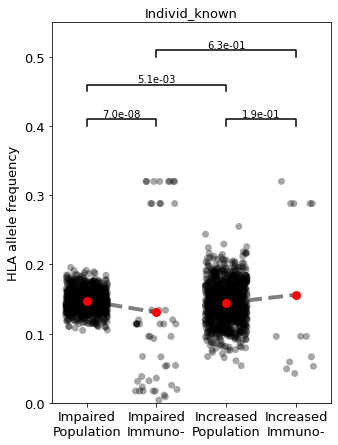

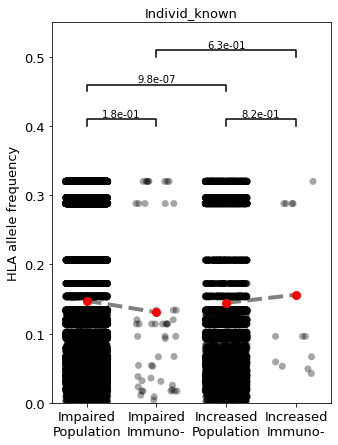

<Figure size 432x288 with 0 Axes>

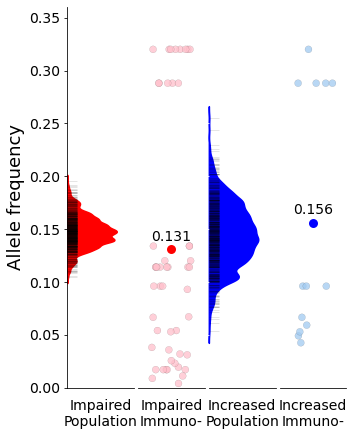

0.876 0.353
(50, 3) (13, 3)


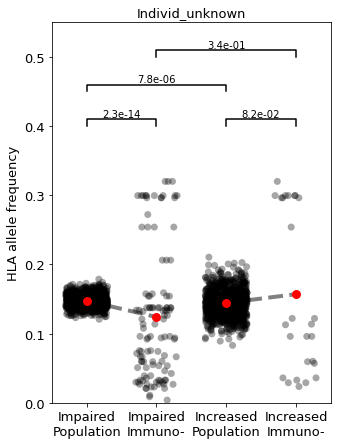

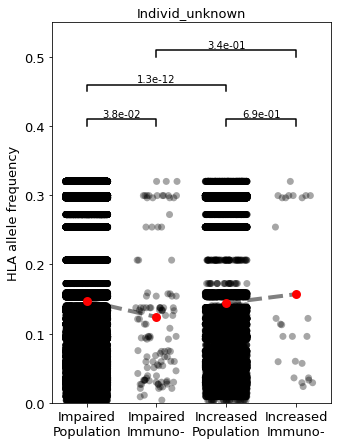

<Figure size 432x288 with 0 Axes>

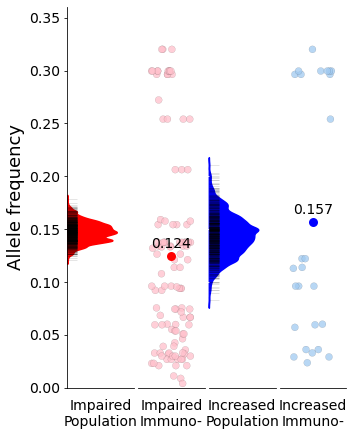

0.998 0.257
(113, 3) (26, 3)


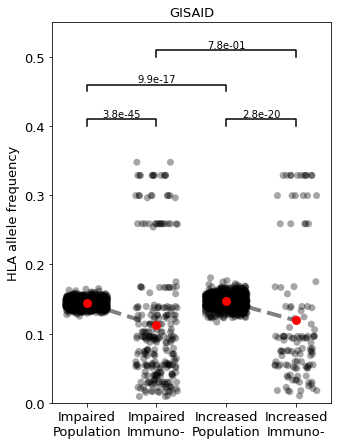

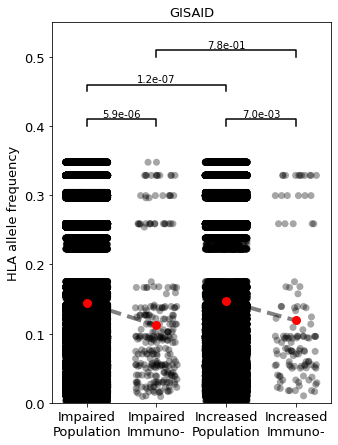

<Figure size 432x288 with 0 Axes>

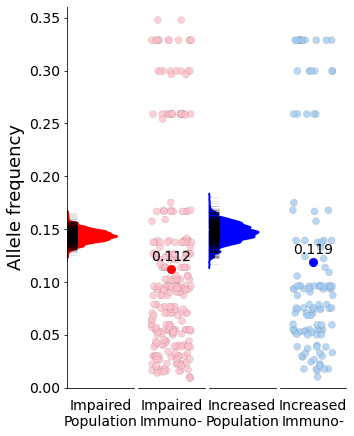

1.0 0.999
(259, 3) (117, 3)


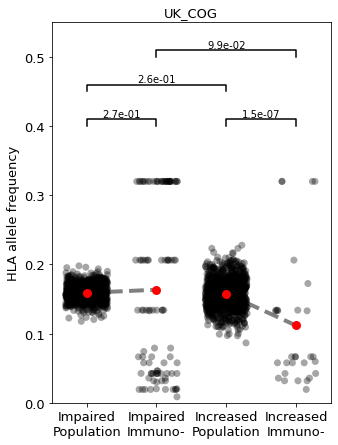

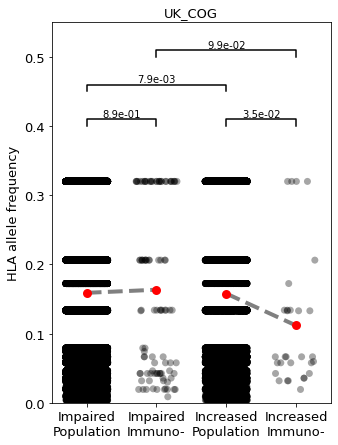

<Figure size 432x288 with 0 Axes>

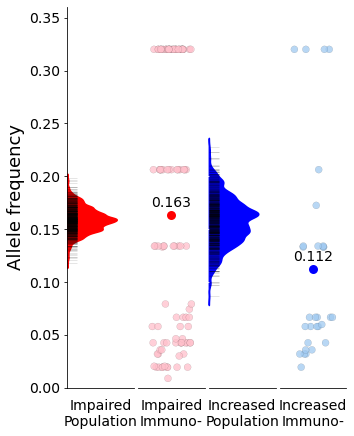

0.341 0.982
(97, 3) (30, 3)


In [8]:
#fig 6
all_c = all_c[~all_c['mutations'].str.contains(',')]


table_sources = [yasya_certain.copy(), yasya_uncertain.copy(), stepa[stepa['Country']!='UnitedKingdom'], stepa[stepa['Country']=='UnitedKingdom']]
names = ['Individ_known', 'Individ_unknown', 'GISAID', 'UK_COG']
for table_source,name in zip(table_sources, names):
    countries_df = set(table_source['Country'])

    lost = table_source[table_source['effect'] == 'impaired']
    incr = table_source[table_source['effect'] == 'increased']
    lost_mean = np.mean(lost['Allele frequency'].astype('float'))
    incr_mean = np.mean(incr['Allele frequency'].astype('float'))

    #n_lost = lost.shape[0]
    #n_incr = incr.shape[0]

    #all_info = pd.DataFrame({'iter_num'[i fir i in range(1000)], ''})
    lost_means = []
    incr_means = []

    lost_iter_freq = []
    incr_iter_freq = []

    nums_lost = []
    nums_incr = []
    for i in range(1000):
        lost_c_tables = []
        incr_c_tables = []
        for c in countries_df:
            tab_c = all_c[(all_c['Country'] == c)]
            n_lost = lost[(lost['Country'] == c)].shape[0]
            n_incr = incr[(incr['Country'] == c)].shape[0]
            tab_c_lost_s = tab_c[tab_c['effect'] == 'impaired'].sample(n = n_lost)
            tab_c_incr_s = tab_c[tab_c['effect'] == 'increased'].sample(n = n_incr)
            lost_c_tables.append(tab_c_lost_s)
            incr_c_tables.append(tab_c_incr_s)
            #print(c, n_lost, tab_c_lost_s.shape[0], n_incr, tab_c_incr_s.shape[0])
        iter_lost = pd.concat(lost_c_tables)
        iter_incr = pd.concat(incr_c_tables)
        iter_lost_mean = np.mean(iter_lost['Allele frequency'])
        iter_incr_mean = np.mean(iter_incr['Allele frequency'])
        lost_means.append(iter_lost_mean)
        incr_means.append(iter_incr_mean)

        lost_iter_freq += list(iter_lost['Allele frequency'].values)
        incr_iter_freq += list(iter_incr['Allele frequency'].values)
        nums_lost += [i for j in range(iter_lost.shape[0])]
        nums_incr += [i for j in range(iter_incr.shape[0])]

    all_info_means = pd.DataFrame({'Allele frequency':lost_means + incr_means + list(lost['Allele frequency'].values) + list(incr['Allele frequency'].values),
                             'x':['impaired_population' for i in range(len(lost_means))] + ['increased_population' for i in range(len(incr_means))] + ['impaired_immunocompromised' for i in range(lost.shape[0])] + ['increased_immunocompromised' for i in range(incr.shape[0])],
                             'num':[i for i in range(len(lost_means))] + [i for i in range(len(lost_means))] + ['imp_immuno' for i in range(lost.shape[0])] + ['incr_immuno' for i in range(incr.shape[0])]})
    all_info_means['Allele frequency'] = all_info_means['Allele frequency'].astype('float')

    all_info_freqs = pd.DataFrame({'Allele frequency':lost_iter_freq + incr_iter_freq + list(lost['Allele frequency'].values) + list(incr['Allele frequency'].values),
                             'x':['impaired_population' for i in range(len(lost_iter_freq))] + ['increased_population' for i in range(len(incr_iter_freq))] + ['impaired_immunocompromised' for i in range(lost.shape[0])] + ['increased_immunocompromised' for i in range(incr.shape[0])],
                                  'num':nums_lost + nums_incr + ['imp_immuno' for i in range(lost.shape[0])] + ['incr_immuno' for i in range(incr.shape[0])]})
    all_info_freqs['Allele frequency'] = all_info_freqs['Allele frequency'].astype('float')


    effects = ['impaired_population','impaired_immunocompromised', 'increased_population', 'increased_immunocompromised']
    for table in [all_info_means, all_info_freqs]:
        fig, ax = plt.subplots(figsize = (5,7))
        ax.set_xticks([0,1,2,3])
        #sns.violinplot(data=table,x="x", y='Allele frequency', inner="point", palette = ['red', 'pink', 'blue', '#A1CAF1'], cut=0,
        #               order = effects,density_norm="count")
        sns.stripplot(x="x", y='Allele frequency', data=table, ax=ax,order = effects,#hue = 'num',split = True,
                              size=7,jitter =0.3, alpha=0.35, color = 'black')

        datas = []
        for eff in effects:
            datas.append(table[table['x'] == eff]['Allele frequency'])
        means1 = pd.DataFrame({'EL_mark':effects, 
                            'medians':[np.mean(datas[0]),np.mean(datas[1]), np.mean(datas[2]),np.mean(datas[3])]})
            #sns.lineplot(x="EL_mark", y='medians', data=medians1, ax=ax,color = 'black',  alpha = 0.75, linestyle = '--', 
            #                lw=4)
        sns.stripplot(x="EL_mark", y='medians', data=means1, ax=ax,color = 'red',  alpha = 1, size = 9, jitter = 0)
        sns.lineplot(x="EL_mark", y='medians', data=means1.head(2), ax=ax,color = 'grey',  alpha = 1, linestyle = '--',lw=4)
        sns.lineplot(x="EL_mark", y='medians', data=means1.tail(2), ax=ax,color = 'grey',  alpha = 1, linestyle = '--',lw=4)

        U1, p1 = mannwhitneyu(datas[0], datas[1])
        barplot_annotate_brackets(0, 1, '%.1e' %p1,[0,1,2,3], [0.35,0.35,0.35,0.35])
        U1, p1 = mannwhitneyu(datas[2], datas[3])
        barplot_annotate_brackets(2, 3, '%.1e' %p1,[0,1,2,3], [0.35,0.35,0.35,0.35])

        U1, p1 = mannwhitneyu(datas[0], datas[2])
        barplot_annotate_brackets(0, 2, '%.1e' %p1,[0,1,2,3], [0.4,0.4,0.4,0.4])
        U1, p1 = mannwhitneyu(datas[1], datas[3])
        barplot_annotate_brackets(1, 3, '%.1e' %p1,[0,1,2,3], [0.45,0.45,0.45,0.45])


        labels = ['Impaired\nPopulation',#\nmed = %.2e' %np.median(datas[0]), 
                      'Impaired\nImmuno-',#\nmed = %.2e' %np.median(datas[1]),
                      'Increased\nPopulation',#\nmed = %.2e' %np.median(datas[2]),
                      'Increased\nImmuno-'#.\nmed = %.2e' %np.median(datas[3])
                 ]
        ax.set_ylim(0,0.55)
        ax.set_xlim(-0.5,3.5)
        ax.set_title(name, fontsize=13)
        ax.set_xticklabels(labels)
        ax.set_ylabel('HLA allele frequency', fontsize=13)
        ax.tick_params(axis = 'both', labelsize=13)
        ax.set_xlabel('')
        #plt.savefig('immuno/Yasya_known.jpg', dpi=300, bbox_inches='tight')
    lost = table_source[table_source['effect'] == 'impaired']
    incr = table_source[table_source['effect'] == 'increased']
    lost_mean = np.mean(lost['Allele frequency'].astype('float'))
    incr_mean = np.mean(incr['Allele frequency'].astype('float'))
    
    picture(all_info_means, lost_mean,incr_mean,'DeltaOmicron_'+name, True)
    print(all_info_means[(all_info_means['x'] == 'impaired_population')&(all_info_means['Allele frequency']>lost_mean)].shape[0]/1000, 
          all_info_means[(all_info_means['x'] == 'increased_population')&(all_info_means['Allele frequency']>incr_mean)].shape[0]/1000)
    print(all_info_means[(all_info_means['x'] == 'impaired_immunocompromised')].shape,all_info_means[(all_info_means['x'] == 'increased_immunocompromised')].shape)